In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
## create signal with two frequencies
## time: sample per sec
dt = 0.001

## dataset samples from 0-1 with sample step 'dt' time
t = np.arange(0, 1, dt)

## two frequencies
## f_raw1 of frequency-50 at 't'
f_raw1 = np.sin(1*np.pi*50*t)

## f_raw2 of frequency-300 at 't'
f_raw2 = np.sin(2*np.pi*300*t)

## clean signal
clean_f = f_raw1+f_raw2

## add noise on the clean_f (clean frequency)
noisy_freq = clean_f + 1.7*np.random.randn(len(t))


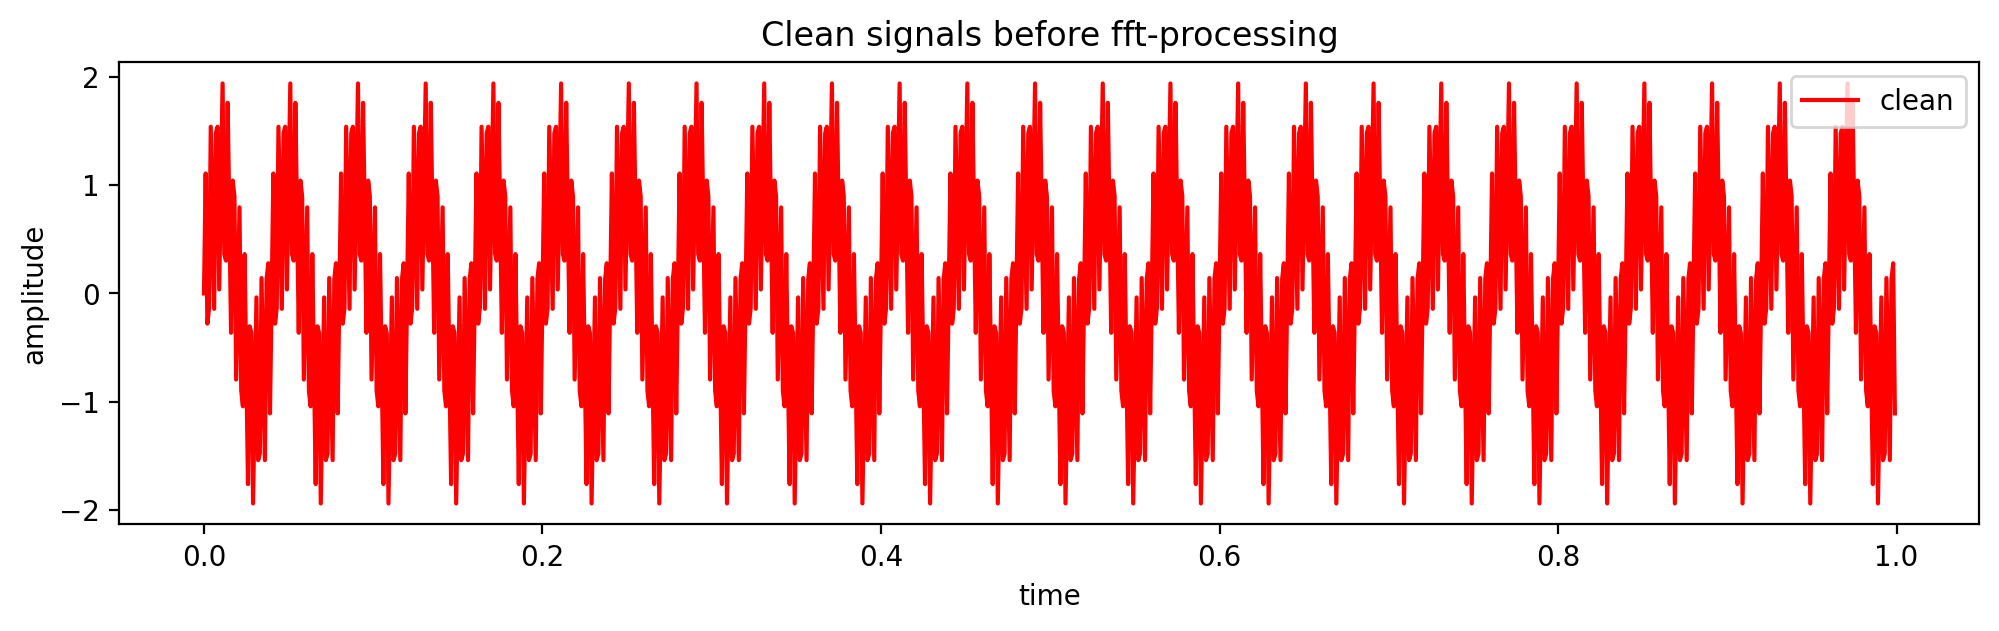

In [39]:
## plot
plt.figure(figsize=(12, 3), dpi=200)
plt.plot(t, clean_f, color='r', label='clean')
plt.xlabel('time')
plt.ylabel('amplitude')
plt.title('Clean signals before fft-processing')
plt.legend()
plt.savefig("plots/clean-initial-signal.png", dpi=200, bbox_inches="tight")
plt.show()

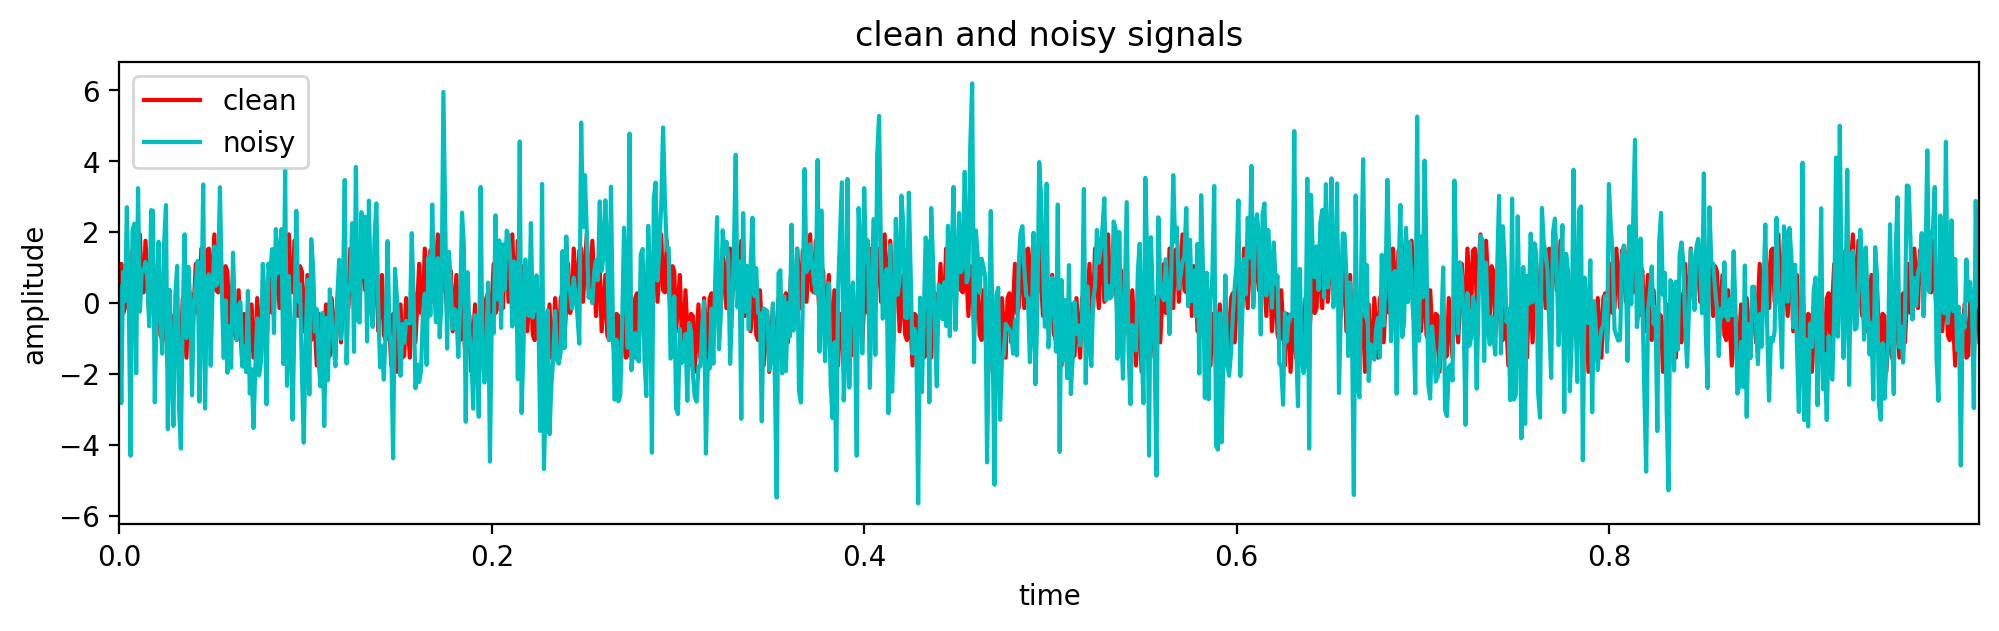

In [3]:
## plot
plt.figure(figsize=(12, 3), dpi=200)
plt.plot(t, clean_f, color='r', label='clean')
plt.plot(t, noisy_freq, color='c', label='noisy')
plt.xlim(t[0],t[-1])
plt.xlabel('time')
plt.ylabel('amplitude')
plt.title('clean and noisy signals')
plt.legend()
plt.savefig("plots/clean_noisy.png", dpi=200, bbox_inches="tight")
plt.show()

# **About Data**
The above dataset sampled under 0.001 per sec and the time interval would be 0 to 1. Eventually, two signals are sampled e.g f_raw1 and f_raw2, these two signals are combine together to form a clean signal. A lots of gaussian noise with the scale of 1.7 has been added to the signal and generates the noise frequency.

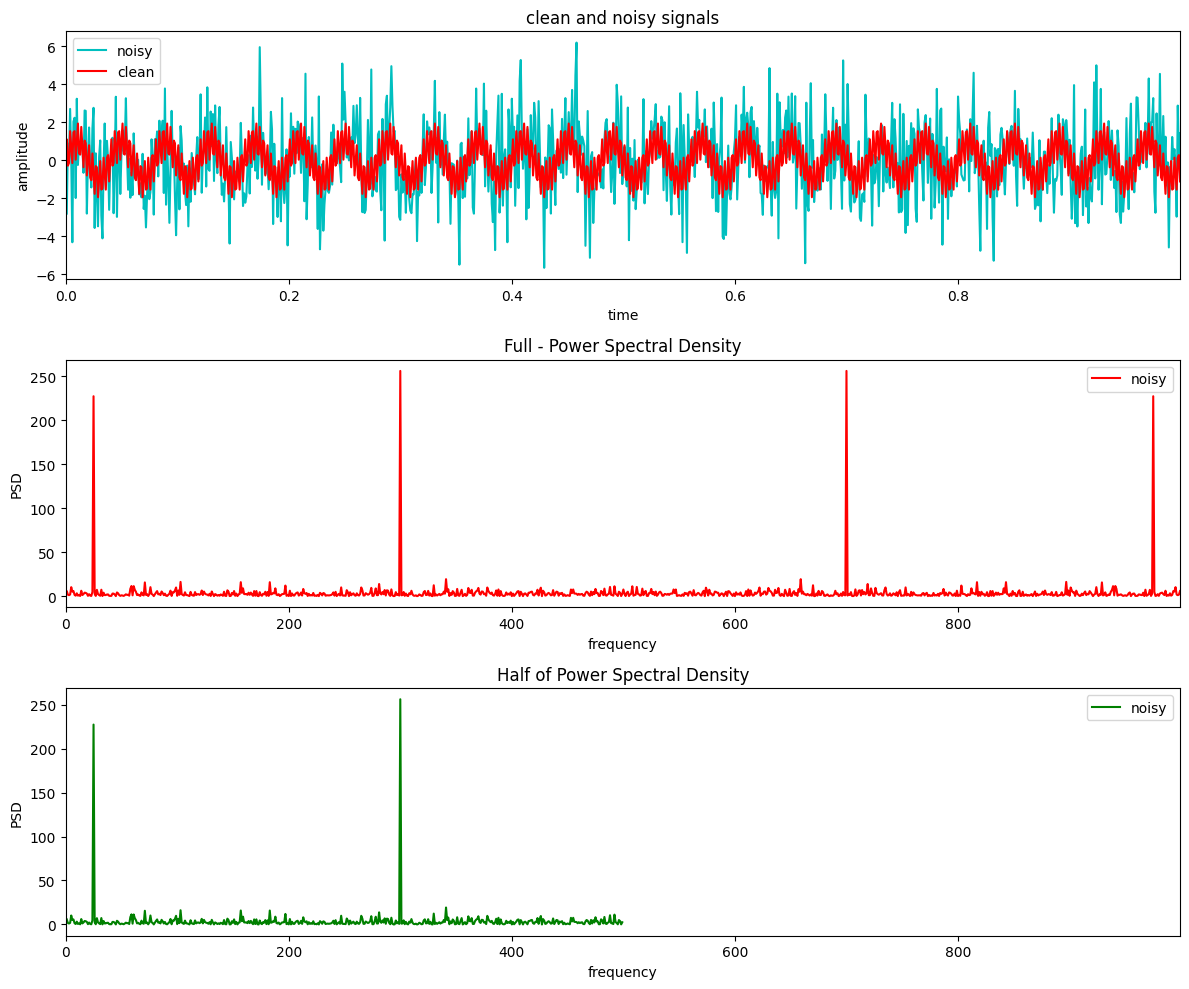

In [ ]:
## compute the Fast Fourier Tansformation
## number of sample(n)/length of datapoints
n = len(t)

## compute the fft on noisy data
fhat = np.fft.fft(noisy_freq, n) ## complex number with magnitude and phase: magnitude tells how important the frequency is? and phase tells you if its more cosine or sine.

## Power spectral Density  (power per frequency)
PSD = fhat * np.conjugate(fhat) / n ## conjugate helps to calculate the real magnitude of the signal

## frequencies vector along x-axis
freq_vec = np.linspace(0, 1/dt, n, endpoint=False) ## same: freq_vec1 = (1/(dt*n)) * np.arange(n)
L = np.arange(1, np.floor(n/2), dtype='int') ## A range of array frome 1 to 500.

## plot
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
axes[0].plot(t, noisy_freq, color = 'c', label='noisy')
axes[0].plot(t, clean_f, color = 'r', label='clean')
axes[0].set_xlim(t[0], t[-1])
axes[0].set_xlabel('time')
axes[0].set_ylabel('amplitude')
axes[0].set_title('clean and noisy signals')
axes[0].legend()


axes[1].plot(freq_vec, PSD, color='r', label ='noisy')
axes[1].set_xlim(freq_vec[0], freq_vec[-1])
axes[1].set_xlabel('frequency')
axes[1].set_ylabel('PSD')
axes[1].set_title('Full - Power Spectral Density')
axes[1].legend()


axes[2].plot(freq_vec[L], PSD[L], color='g', label ='noisy')
axes[2].set_xlim(freq_vec[0], freq_vec[-1])
axes[2].set_xlabel('frequency')
axes[2].set_ylabel('PSD')
axes[2].set_title('Half of Power Spectral Density')
axes[2].legend()
plt.tight_layout()
plt.show()


## **Power Spectral Density (PSD)**:
 It is very closely related to magnitude, but it is not just the magnitude; it is the magnitude squared, spread out across different frequencies, and normalized by frequency bandwidth. If magnitude tells you "how strong the overall signal is?", PSD tells you "how much power is packed into each specific frequency band." Y-axis is the power.



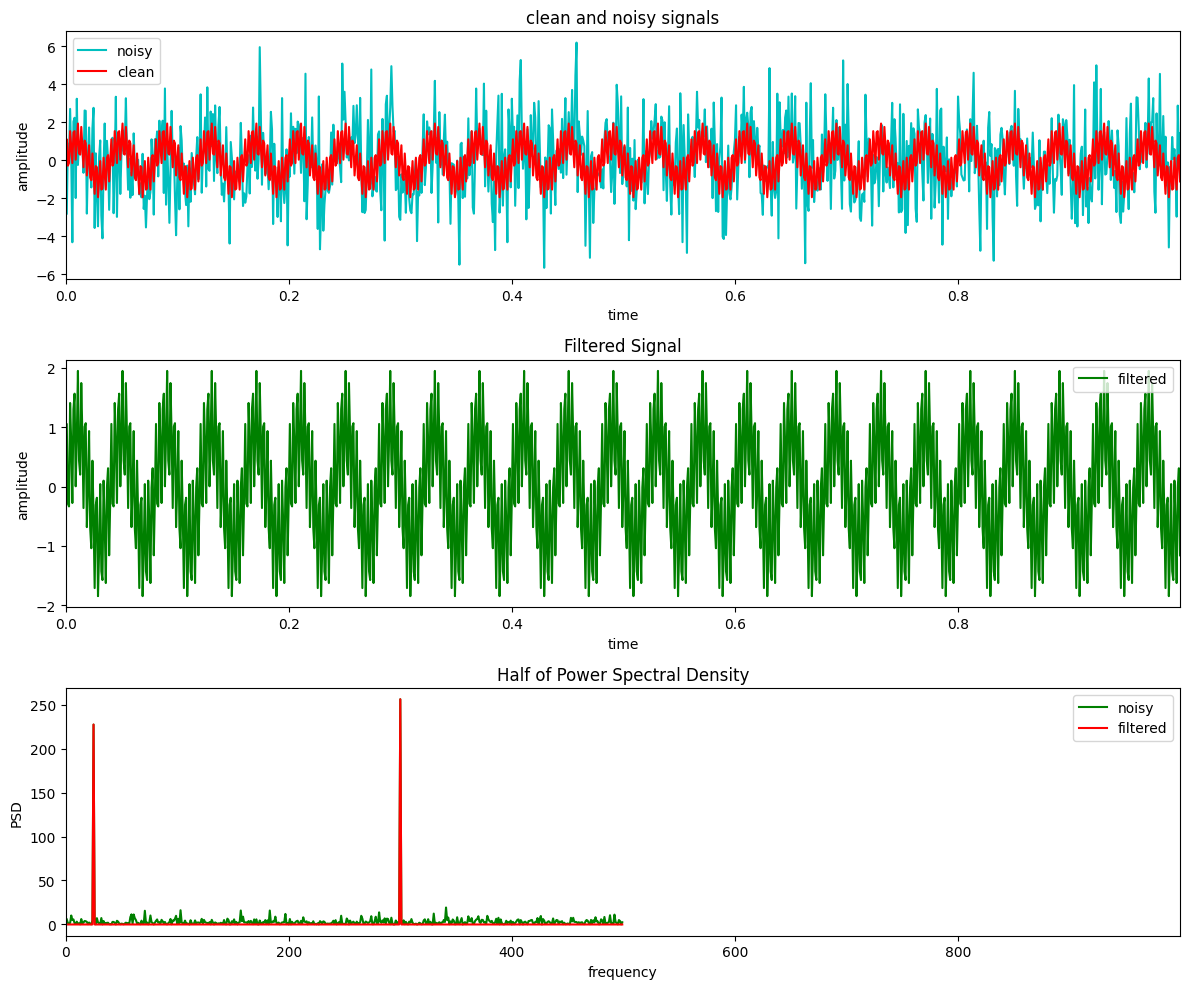

In [5]:
## Use PSD to filter out noisy frequencies
indices = PSD>100 ## find all frequencies with large power

## each rows of PSD has the frequecies values
PSD_clean = PSD * indices ## zero out all psd lower than a threshold value

fhat_clean = fhat * indices ## zero out all small frequency coefficient on Y axis

## perform inverse Fast Fourier Transform to get clean signal
clean_fft = np.fft.ifft(fhat_clean) ## Inverse FFT for filtered time signal

## plot
fig, axes = plt.subplots(3,1, figsize=(12, 10))
axes[0].plot(t, noisy_freq, color = 'c', label='noisy')
axes[0].plot(t, clean_f, color = 'r', label='clean')
axes[0].set_xlim(t[0], t[-1])
axes[0].set_xlabel('time')
axes[0].set_ylabel('amplitude')
axes[0].set_title('clean and noisy signals')
axes[0].legend()

axes[1].plot(t, clean_fft, color='g', label ='filtered')
axes[1].set_xlim(t[0], t[-1])
axes[1].set_xlabel('time')
axes[1].set_ylabel('amplitude')
axes[1].set_title('Filtered Signal')
axes[1].legend()

axes[2].plot(freq_vec[L], PSD[L], color='g', label ='noisy')
axes[2].plot(freq_vec[L], PSD_clean[L], color='r', label ='filtered')
axes[2].set_xlim(freq_vec[0], freq_vec[-1])
axes[2].set_xlabel('frequency')
axes[2].set_ylabel('PSD')
axes[2].set_title('Half of Power Spectral Density')
axes[2].legend()

plt.tight_layout()
plt.show()


## **Noisy Signals**

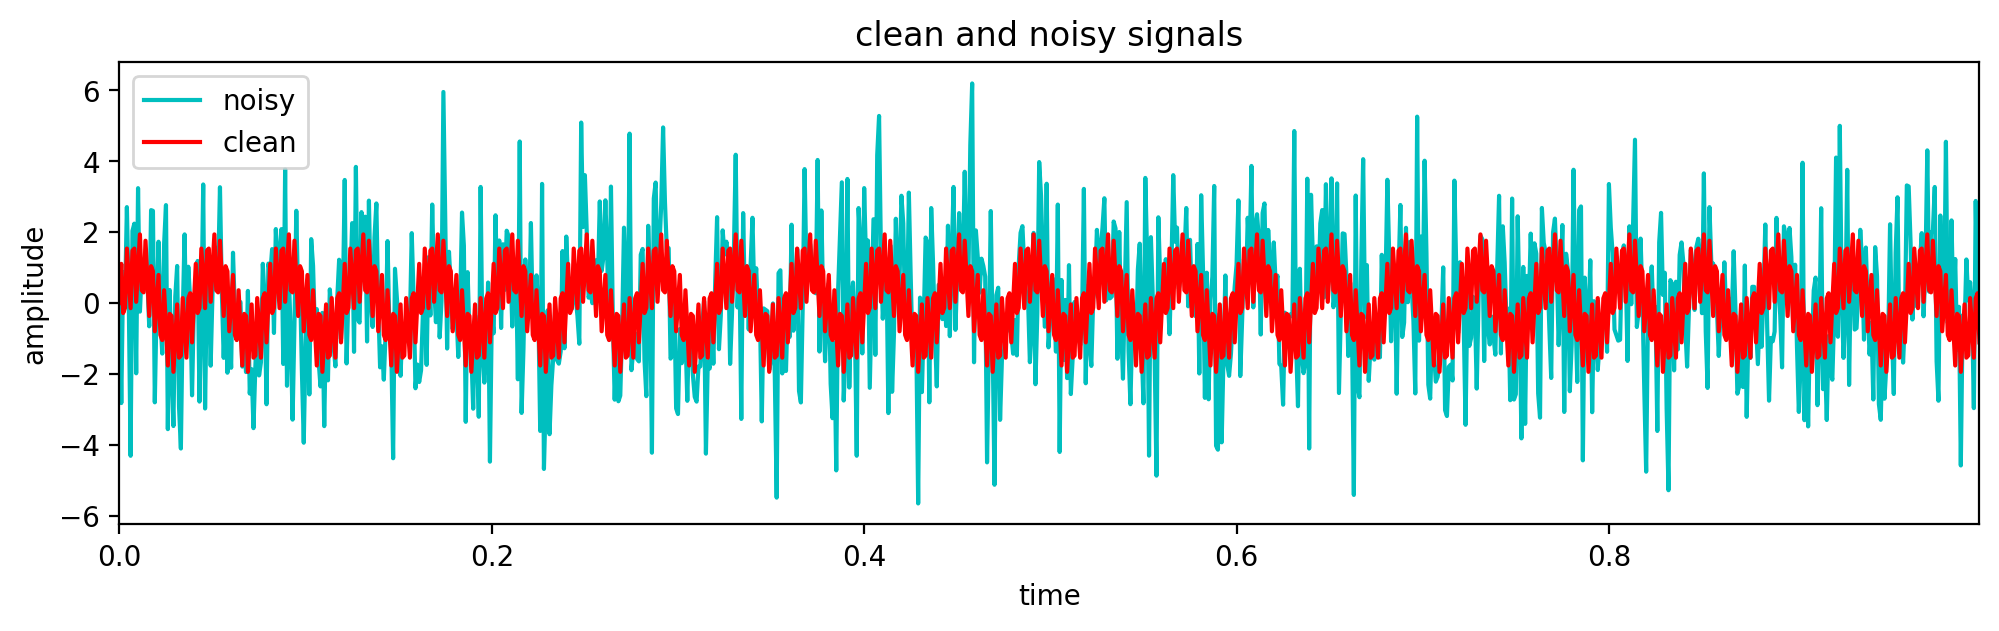

In [6]:
plt.figure(figsize=(12,3), dpi=200)
plt.plot(t, noisy_freq, color = 'c', label='noisy')
plt.plot(t, clean_f, color = 'r', label='clean')
plt.xlim(t[0], t[-1])
plt.xlabel('time')
plt.ylabel('amplitude')
plt.title('clean and noisy signals')
plt.legend()
plt.savefig("plots/clean-noisy-signals", dpi=200, bbox_inches="tight")
plt.show()

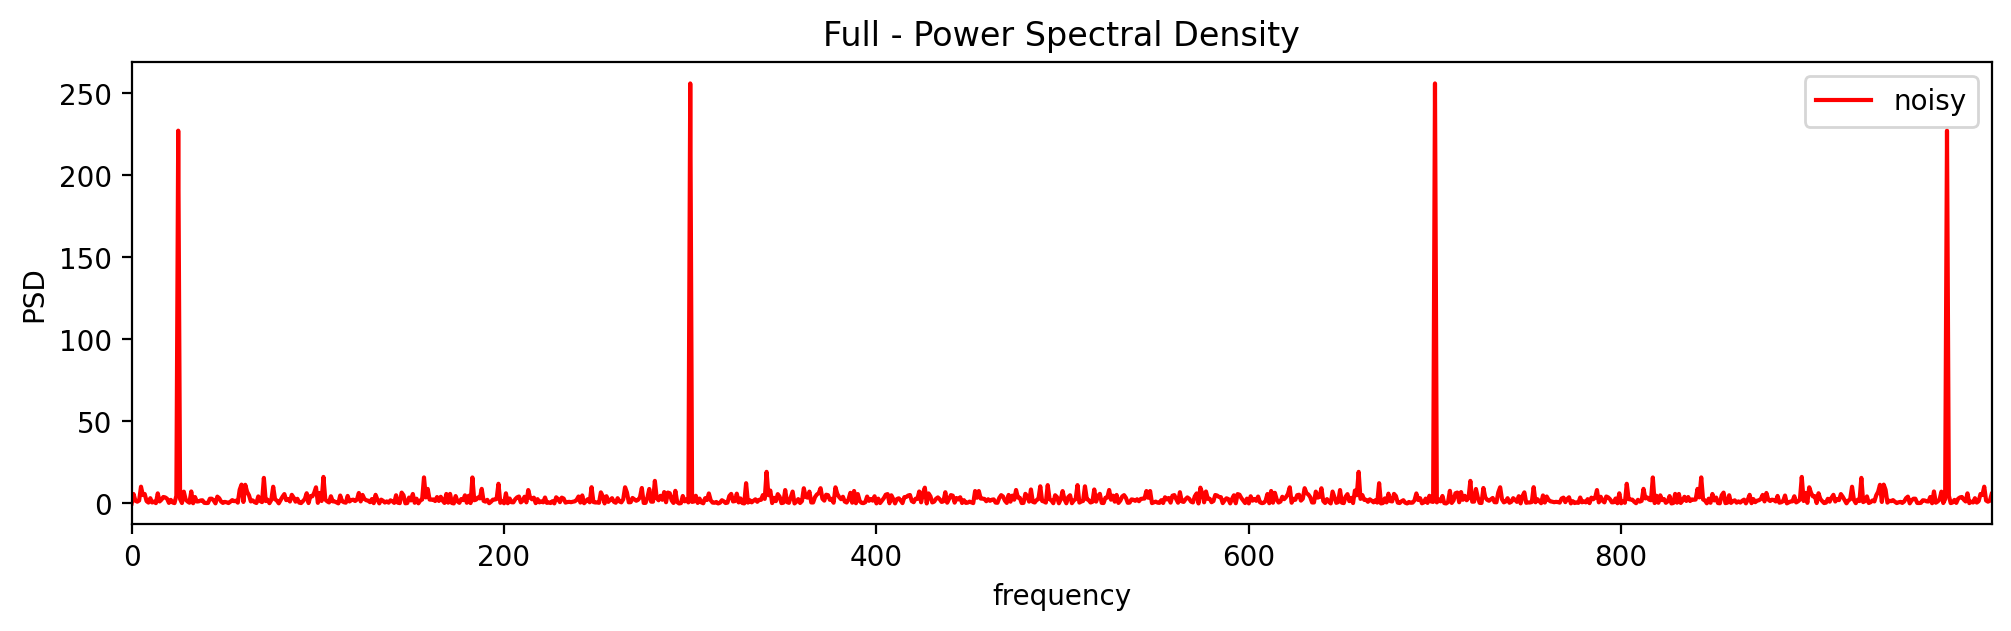

In [7]:
plt.figure(figsize=(12,3), dpi=200)
plt.plot(freq_vec, PSD, color='r', label ='noisy')
plt.xlim(freq_vec[0], freq_vec[-1])
plt.xlabel('frequency')
plt.ylabel('PSD')
plt.title('Full - Power Spectral Density')
plt.legend()
plt.savefig("plots/full-power-spectral-density", dpi=200, bbox_inches="tight")
plt.show()


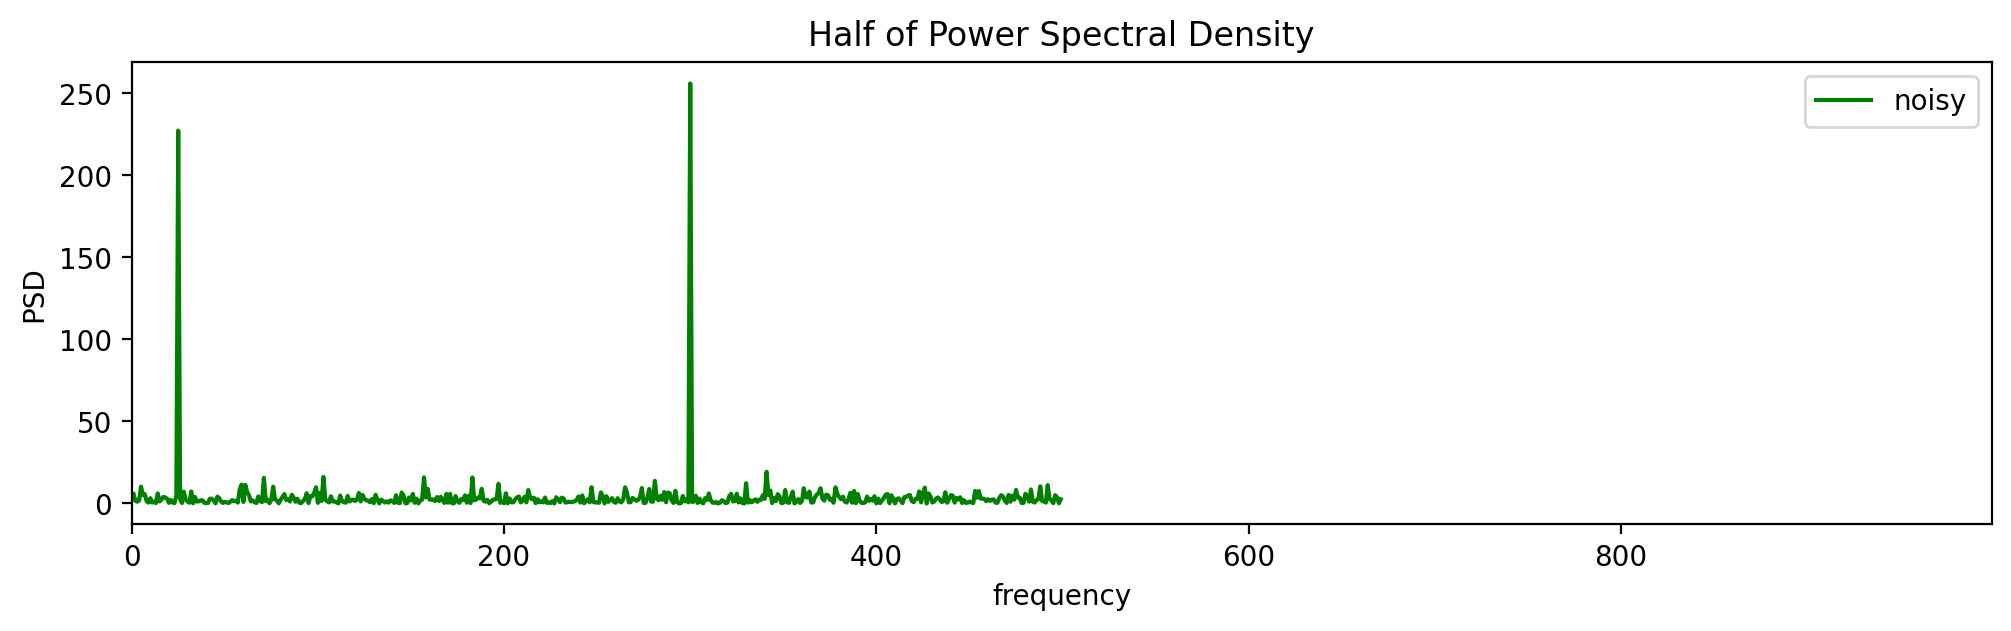

In [8]:
plt.figure(figsize=(12,3), dpi=200)
plt.plot(freq_vec[L], PSD[L], color='g', label ='noisy')
plt.xlim(freq_vec[0], freq_vec[-1])
plt.xlabel('frequency')
plt.ylabel('PSD')
plt.title('Half of Power Spectral Density')
plt.legend()
plt.savefig("plots/half-power-spectral-density", dpi=200, bbox_inches="tight")
plt.show()

## **Applied PSD: Single Plots**

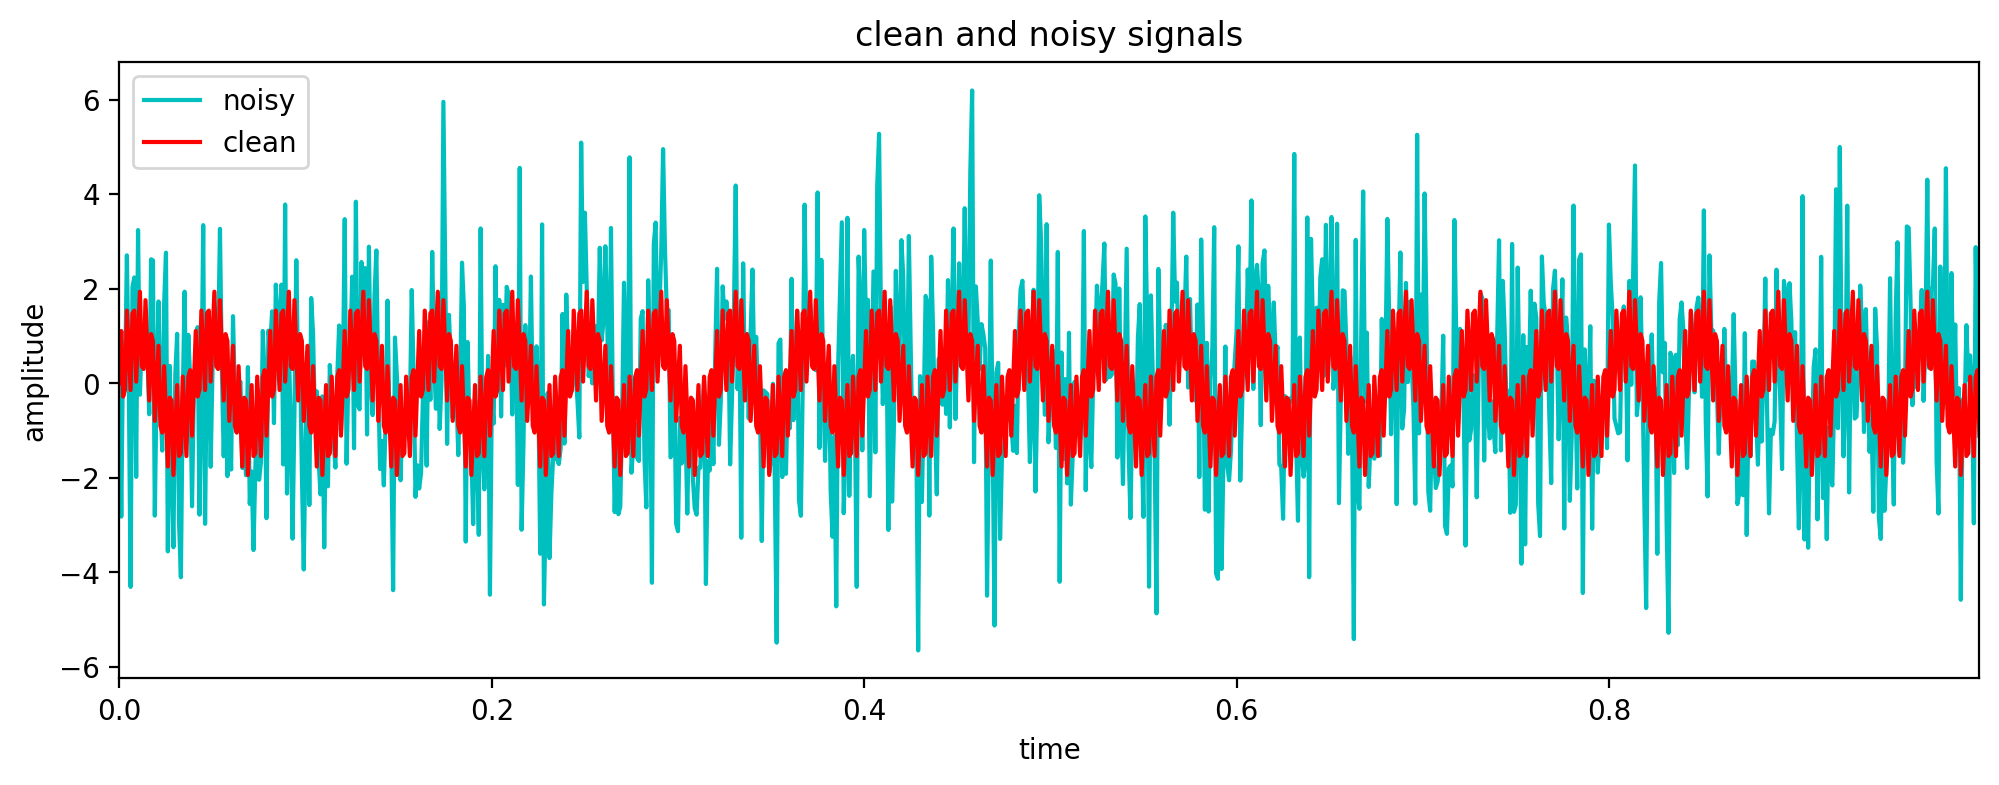

In [9]:
plt.figure(figsize=(12,4), dpi=200)
plt.plot(t, noisy_freq, color = 'c', label='noisy')
plt.plot(t, clean_f, color = 'r', label='clean')
plt.xlim(t[0], t[-1])
plt.xlabel('time')
plt.ylabel('amplitude')
plt.title('clean and noisy signals')
plt.legend()
plt.savefig("plots/clean-noisy", dpi=200, bbox_inches="tight")
plt.show()

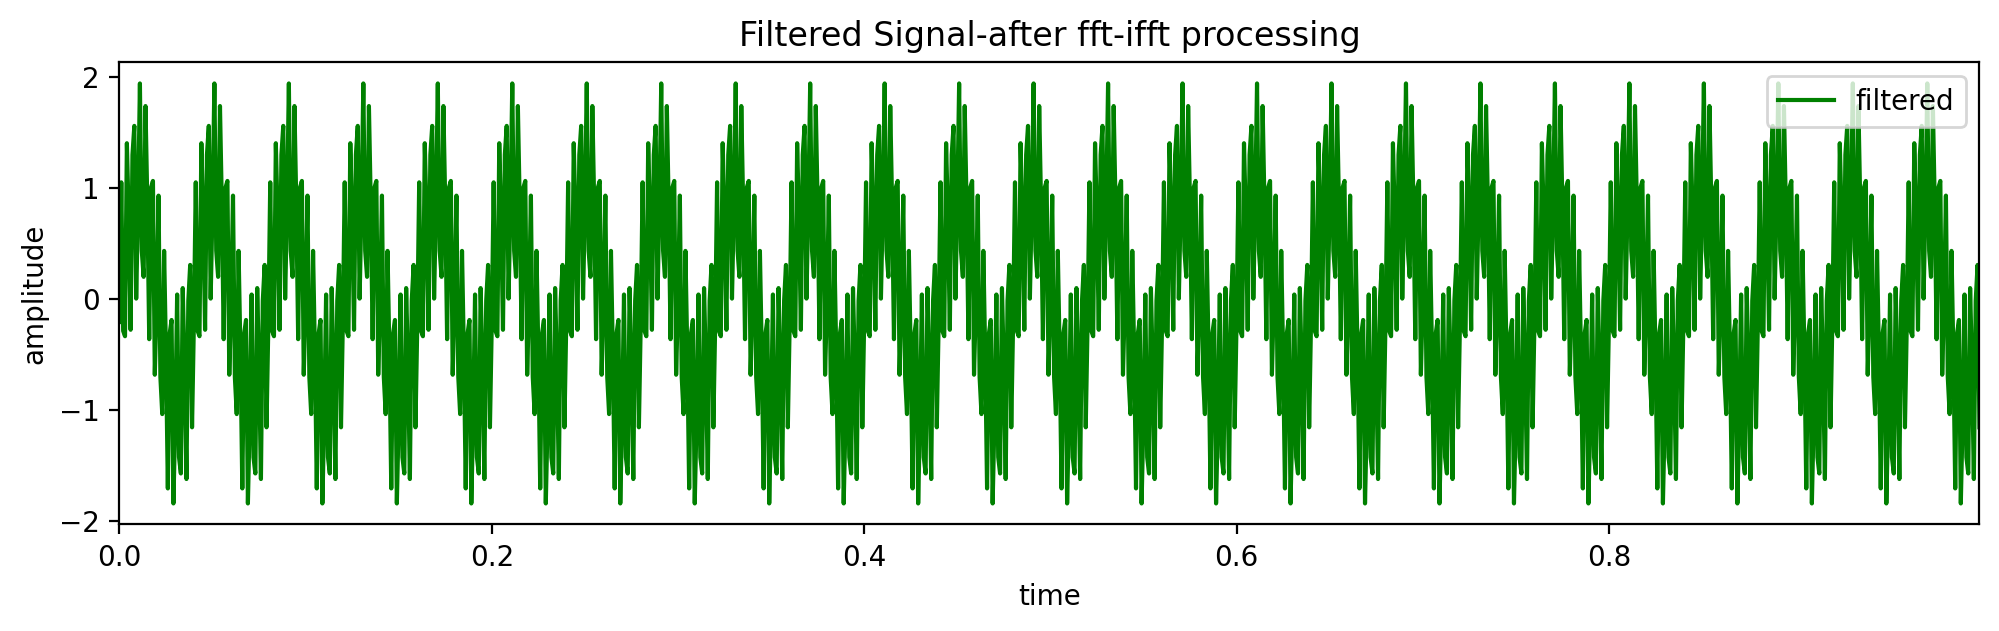

In [37]:
plt.figure(figsize=(12,3), dpi= 200)
plt.plot(t, clean_fft, color='g', label ='filtered')
plt.xlim(t[0], t[-1])
plt.xlabel('time')
plt.ylabel('amplitude')
plt.title('Filtered Signal-after fft-ifft processing')
plt.legend()
plt.savefig("plots/filtered-signal", dpi=200, bbox_inches="tight")
plt.show()

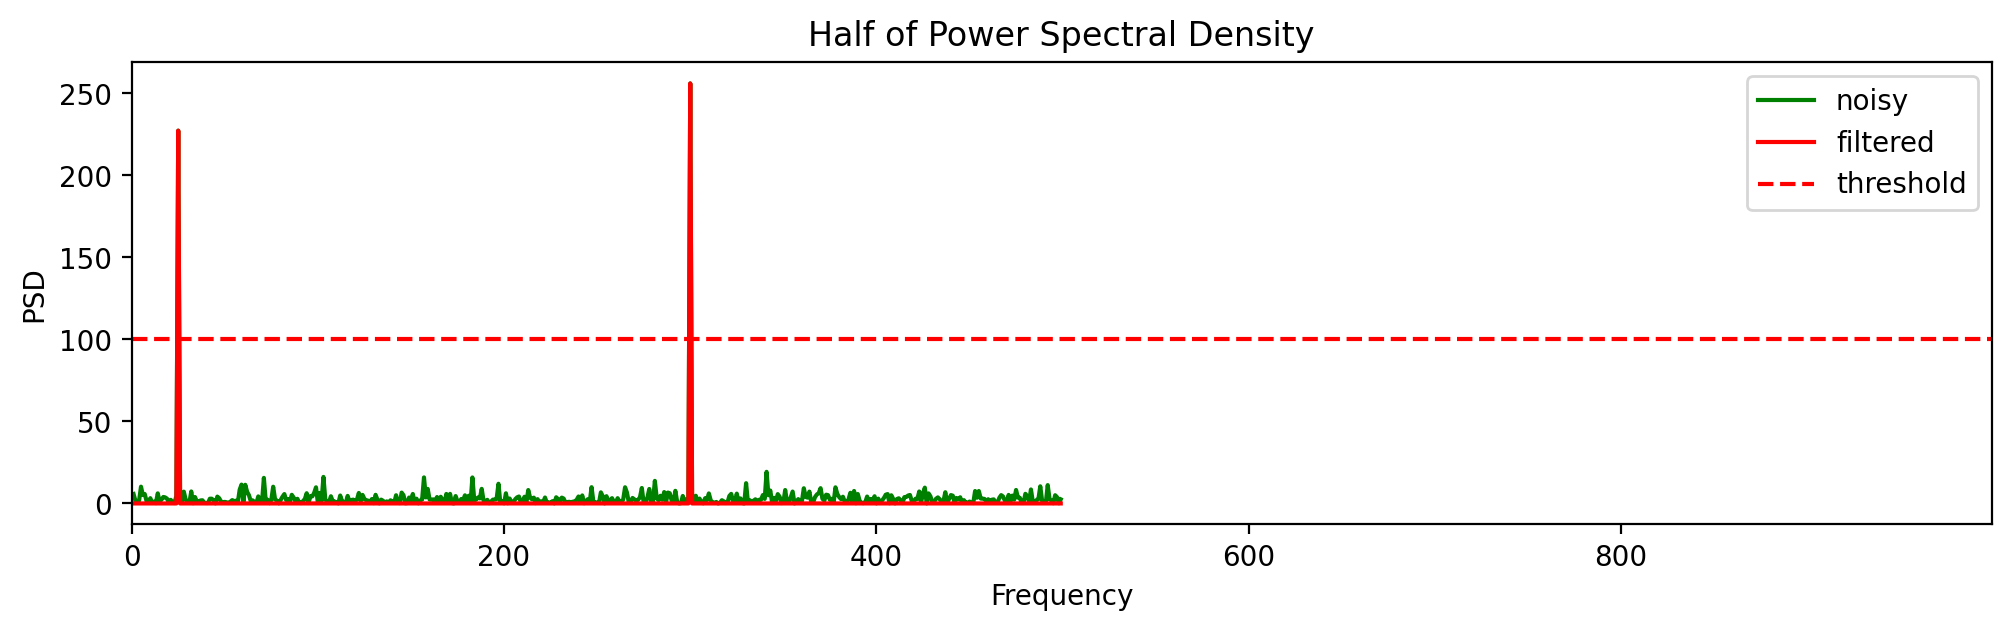

In [34]:
plt.figure(figsize=(12,3), dpi= 200)
plt.plot(freq_vec[L], PSD[L], color='g', label ='noisy')
plt.plot(freq_vec[L], PSD_clean[L], color='r', label ='filtered')
plt.axhline(y=100, color='r', linestyle='--', label='threshold')
plt.xlim(freq_vec[0], freq_vec[-1])
plt.xlabel('Frequency')
plt.ylabel('PSD')
plt.title('Half of Power Spectral Density')
plt.legend()
plt.savefig("plots/half-clean-noisy-psd-threshold", dpi=200, bbox_inches="tight")
plt.show()

## **Plot the Complex Plane (Real vs. Imaginary)**

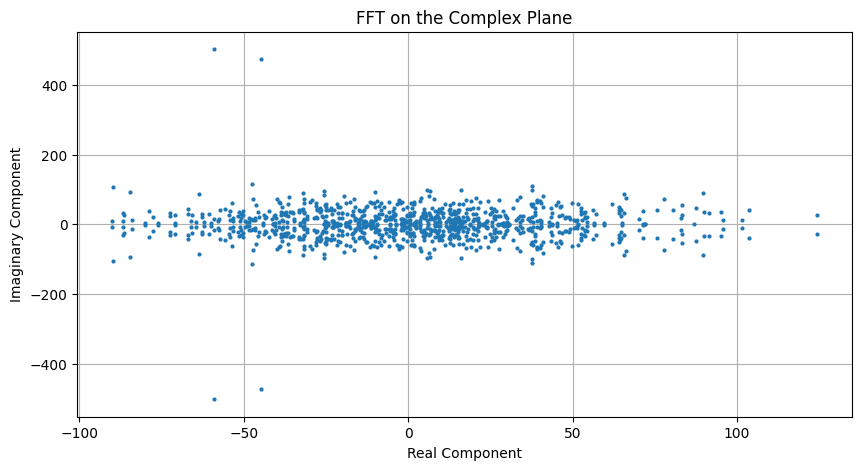

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming fhat is your complex FFT array
plt.figure(figsize=(10,5))
plt.plot(fhat.real, fhat.imag, 'o', markersize=2)
plt.title("FFT on the Complex Plane")
plt.xlabel("Real Component")
plt.ylabel("Imaginary Component")
plt.grid(True)
plt.savefig("plots/fft-complex-plane.png", dpi=200, bbox_inches="tight")
plt.show()


In [18]:
import seaborn as sns

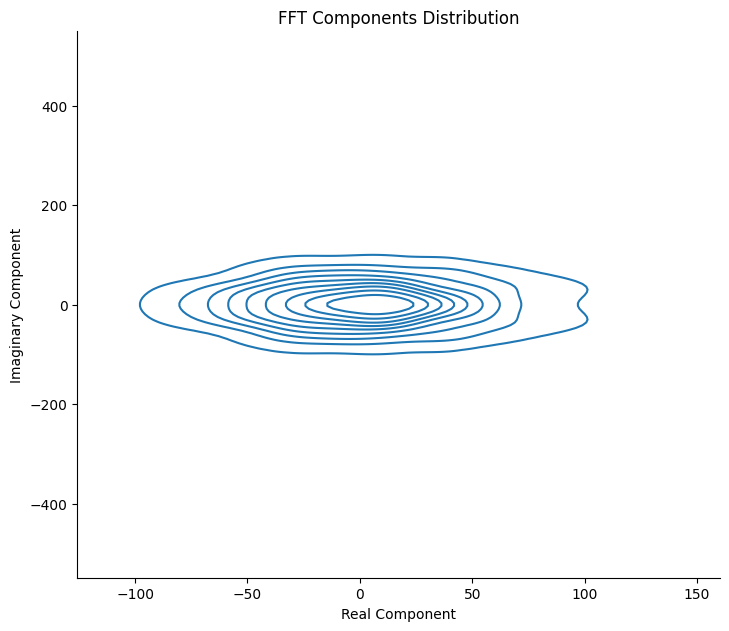

In [23]:
sns.displot(
    x=fhat.real,
    y=fhat.imag,
    kind="kde",
    height=6,
    aspect=1.2
)

plt.xlabel("Real Component")
plt.ylabel("Imaginary Component")
plt.title("FFT Components Distribution")
plt.show()

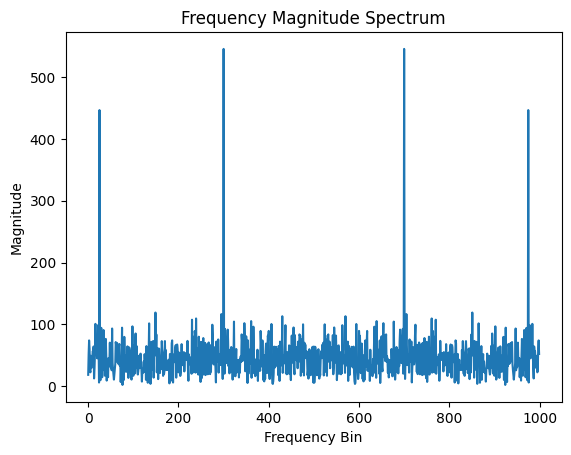

In [ ]:
plt.figure()
plt.plot(np.abs(fhat))
plt.title("Frequency Magnitude Spectrum")
plt.xlabel("Frequency Bin")
plt.ylabel("Magnitude")
plt.show()


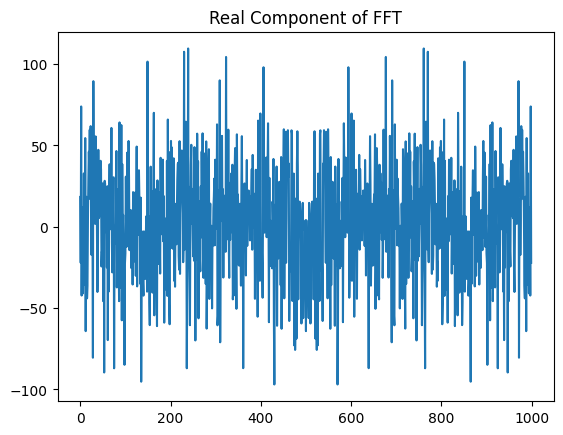

In [ ]:
plt.figure()
plt.plot(fhat.real)
plt.title("Real Component of FFT")
plt.show()


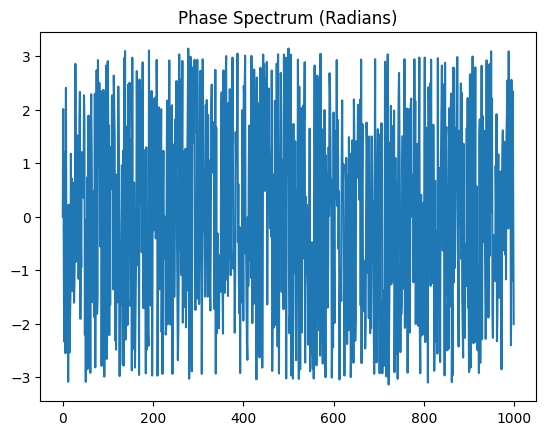

In [ ]:
plt.figure()
plt.plot(np.angle(fhat))
plt.title("Phase Spectrum (Radians)")
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
%pip install plotly

# Generate a sample noisy signal
Fs = 1000  # Sampling frequency
t = np.linspace(0, 1, Fs, endpoint=False)
clean_signal = np.sin(2 * np.pi * 50 * t) + 0.5 * np.sin(2 * np.pi * 120 * t)
noise = np.random.normal(0, 1.5, size=t.shape)
noisy_freq = clean_signal + noise

#Compute FFT
n = 512
fhat = np.fft.fft(noisy_freq, n)
frequencies = np.fft.fftfreq(n, d=1/Fs)

# Filter for the positive frequencies only to cleanly see the peaks
half_idx = frequencies >= 0
x_freq = frequencies[half_idx]
y_real = fhat.real[half_idx]
z_imag = fhat.imag[half_idx]
magnitude = np.abs(fhat)[half_idx]

# Package data into a Pandas DataFrame for Plotly Express
df = pd.DataFrame({
    'Frequency (Hz)': x_freq,
    'Real (cos)': y_real,
    'Imaginary (sin)': z_imag,
    'Magnitude': magnitude
})

# 4. Generate the dynamic 3D Line Plot
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=df['Frequency (Hz)'],
            y=df['Real (cos)'],
            z=df['Imaginary (sin)'],
            mode='lines',
            line=dict(
                color=df['Magnitude'],
                colorscale='Viridis',
                showscale=True,
                colorbar=dict(title='Magnitude')
            )
        )
    ]
)
fig.update_layout(title='Interactive 3D Complex FFT Spectrum')

# Enhance layout controls for better 3D spinning interaction
fig.update_layout(
    scene=dict(
        xaxis_title='Frequency (Hz)',
        yaxis_title='Real [cos]',
        zaxis_title='Imag (sin)'
    ),
    margin=dict(l=0, r=0, b=0, t=40) # Maximize screen space
)

# Render graph in your browser or notebook
fig.show()


Note: you may need to restart the kernel to use updated packages.


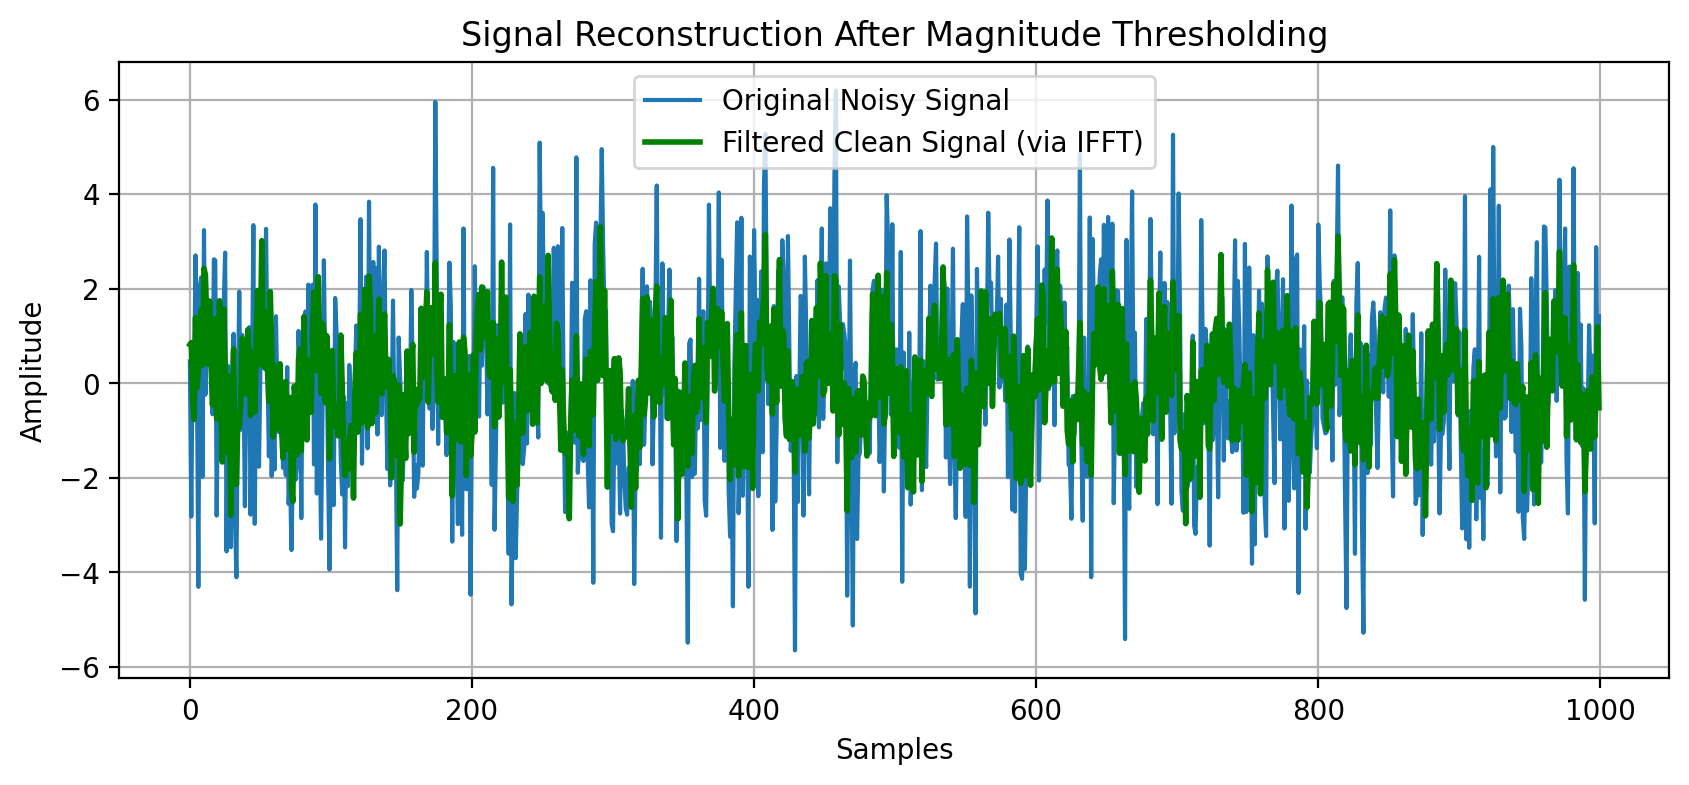

In [50]:
#Assume fhat and noisy_freq are already calculated from your previous steps
# fhat = np.fft.fft(noisy_freq, n)

#Apply your analytical threshold filter
threshold = 100
fhat_clean = np.where(np.abs(fhat) > threshold, fhat, 0.0)

#Reconstruct the clean time-domain signal using Inverse FFT (IFFT)
# We take the real part (.real) because minor floating-point errors can leave tiny imaginary residues
reconstructed_signal = np.fft.ifft(fhat_clean).real

#Truncate back to original signal length if n was larger than the sample count
# (e.g., if you padded n=512 for a 500-sample signal)
reconstructed_signal = reconstructed_signal[:len(noisy_freq)]

#Plot the results to witness the denoising
plt.figure(figsize=(10, 4), dpi=200)
plt.plot(noisy_freq, label='Original Noisy Signal')
plt.plot(reconstructed_signal, label='Filtered Clean Signal (via IFFT)', color='green', linewidth=2)
plt.title('Signal Reconstruction After Magnitude Thresholding')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.savefig("plots/signal-recons-threshold.png", dpi=200, bbox_inches="tight")
plt.show()
